In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

# Tricura EDA
## 1. Data Loading & Inventory

In [2]:
DATA_DIR = Path("data")

dfs = {p.stem: pd.read_parquet(p) for p in sorted(DATA_DIR.glob("*.parquet"))}

inventory = pd.DataFrame(
    [
        {
            "dataset": name,
            "rows": df.shape[0],
            "cols": df.shape[1],
            "size_mb": round(DATA_DIR.joinpath(f"{name}.parquet").stat().st_size / 1e6, 2),
            "dtypes": df.dtypes.value_counts().to_dict(),
        }
        for name, df in dfs.items()
    ]
).sort_values("size_mb", ascending=False).reset_index(drop=True)

inventory

,dataset,rows,cols,size_mb,dtypes
0,vitals,2517056,9,131.1100,"{str: 4, float64: 2, datetime64[us]: 2, bool: 1}"
1,medications,1430877,8,65.4000,"{str: 5, datetime64[us]: 3}"
2,gg_responses,660711,10,26.9900,"{str: 6, float64: 3, datetime64[us]: 1}"
3,document_tags,562905,9,23.5200,"{str: 5, datetime64[us]: 2, float64: 1, object..."
4,adl_responses,480554,12,19.7200,"{str: 9, datetime64[us]: 2, int64: 1}"
5,needs,162762,11,8.1700,"{str: 6, datetime64[us]: 3, bool: 2}"
6,factors,190284,5,8.0300,"{str: 4, datetime64[us]: 1}"
7,physician_orders,94051,10,5.5900,"{str: 6, datetime64[us]: 4}"
8,diagnoses,60620,8,2.9900,"{str: 4, datetime64[us]: 3, bool: 1}"
9,lab_reports,13334,9,0.8900,"{str: 6, datetime64[us]: 3}"


In [3]:
# Column names and dtypes per dataset
for name, df in dfs.items():
    print(f"\n{'='*60}")
    print(f"  {name}  ({df.shape[0]:,} rows x {df.shape[1]} cols)")
    print(f"{'='*60}")
    print(df.dtypes.to_string())


  adl_responses  (480,554 rows x 12 cols)
adl_response_id                    str
resident_id                        str
facility_id                        str
assessment_date         datetime64[us]
activity                           str
category                           str
response                           str
response_description               str
response_status                    str
previous_response                  str
adl_change                       int64
created_at              datetime64[us]

  care_plans  (3,034 rows x 9 cols)
care_plan_id                 str
resident_id                  str
facility_id                  str
initiated_at      datetime64[us]
closed_reason                str
closed_at         datetime64[us]
next_review_at    datetime64[us]
strikeout                   bool
created_at        datetime64[us]

  diagnoses  (60,620 rows x 8 cols)
diagnosis_id               str
facility_id                str
resident_id                str
icd_10_code              

## 2. Data Quality — Duplicates & Missing Values

In [4]:
quality_rows = []
for name, df in dfs.items():
    n = len(df)
    dup_rows = df.duplicated().sum()
    null_cols = (df.isnull().sum() > 0).sum()
    null_total = df.isnull().sum().sum()
    null_pct = 100 * null_total / (n * df.shape[1]) if n > 0 else 0
    quality_rows.append(
        dict(
            dataset=name,
            rows=n,
            duplicate_rows=dup_rows,
            dup_pct=round(100 * dup_rows / n, 2) if n else 0,
            cols_with_nulls=null_cols,
            total_nulls=null_total,
            null_pct=round(null_pct, 2),
        )
    )

quality = pd.DataFrame(quality_rows)
quality

,dataset,rows,duplicate_rows,dup_pct,cols_with_nulls,total_nulls,null_pct
0,adl_responses,480554,0,0.0000,1,1445,0.0300
1,care_plans,3034,0,0.0000,2,2232,8.1700
2,diagnoses,60620,0,0.0000,3,56296,11.6100
3,document_tags,562905,0,0.0000,3,818089,16.1500
4,factors,190284,0,0.0000,0,0,0.0000
5,gg_responses,660711,0,0.0000,3,361518,5.4700
6,hospital_admissions,2945,0,0.0000,4,4523,17.0600
7,hospital_transfers,1816,0,0.0000,6,974,4.4700
8,incidents,3578,0,0.0000,1,1,0.0000
9,injuries,1219,0,0.0000,0,0,0.0000


In [5]:
# Per-column null breakdown for datasets that have nulls
for name, df in dfs.items():
    null_s = df.isnull().sum()
    null_s = null_s[null_s > 0]
    if null_s.empty:
        continue
    print(f"\n{name}")
    null_df = pd.DataFrame({
        "null_count": null_s,
        "null_pct": (100 * null_s / len(df)).round(2)
    }).sort_values("null_pct", ascending=False)
    print(null_df.to_string())


adl_responses
                   null_count  null_pct
previous_response        1445    0.3000

care_plans
               null_count  null_pct
closed_reason        1116   36.7800
closed_at            1116   36.7800

diagnoses
             null_count  null_pct
resolved_at       52988   87.4100
onset_at           3049    5.0300
icd_10_code         259    0.4300

document_tags
                  null_count  null_pct
deleted_at            562840   99.9900
match_confidence      127822   22.7100
editable              127427   22.6400

gg_responses
                        null_count  null_pct
change                      313394   47.4300
previous_response_code       24624    3.7300
response_code                23500    3.5600

hospital_admissions
                  null_count  null_pct
emergency_flag          2945  100.0000
hospital_stay_to        1478   50.1900
admission_status          79    2.6800
ineffective_date          21    0.7100

hospital_transfers
                  null_count  null_pc

## 3. Descriptive Statistics

In [6]:
# Numeric descriptive statistics per dataset
for name, df in dfs.items():
    num_cols = df.select_dtypes(include="number").columns.tolist()
    if not num_cols:
        continue
    print(f"\n{'='*60}  {name}  {'='*60}")
    display(df[num_cols].describe().T.round(4))


============================================================  adl_responses  ============================================================


,count,mean,std,min,25%,50%,75%,max
adl_change,480554.0000,0.0006,0.7375,-4.0000,0.0000,0.0000,0.0000,4.0000



============================================================  document_tags  ============================================================


,count,mean,std,min,25%,50%,75%,max
match_confidence,435083.0000,0.8327,0.2280,0.2006,0.7074,0.9679,0.9979,1.0000



============================================================  gg_responses  ============================================================


,count,mean,std,min,25%,50%,75%,max
response_code,637211.0000,5.6261,7.3966,1.0000,2.0000,5.0000,9.0000,88.0000
previous_response_code,636087.0000,5.7250,7.3191,1.0000,2.0000,5.0000,9.0000,88.0000
change,347317.0000,-0.0098,1.6227,-5.0000,0.0000,0.0000,0.0000,5.0000



============================================================  vitals  ============================================================


,count,mean,std,min,25%,50%,75%,max
value,2517056.0000,70.9482,76.1766,0.0000,0.0000,78.0000,100.0000,19999.0000
dystolic_value,370662.0000,72.5419,79.3944,0.0000,66.0000,72.0000,78.0000,45941.0000


In [7]:
# Categorical / object columns — top value counts per column
for name, df in dfs.items():
    cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    if not cat_cols:
        continue
    print(f"\n{'='*60}  {name}  {'='*60}")
    for col in cat_cols:
        vc = df[col].value_counts(dropna=False).head(10)
        pct = (100 * vc / len(df)).round(2)
        tbl = pd.DataFrame({"count": vc, "pct": pct})
        print(f"\n  [{col}]  ({df[col].nunique()} unique)")
        print(tbl.to_string())


============================================================  adl_responses  ============================================================

  [adl_response_id]  (480554 unique)
                                      count    pct
adl_response_id                                   
ba6980c7-9fa3-50a0-9675-0e04f20c1d87      1 0.0000
0cb400f7-0a78-5a7a-875c-ff242e2bc54c      1 0.0000
0ce7b538-e887-5098-ac95-575603d2ac3e      1 0.0000
cadd23d3-3838-5360-bc7c-74e753a15517      1 0.0000
bfa06183-64ca-5d2f-977f-18fc65cfefad      1 0.0000
4f95176d-82bc-5008-96b2-b6d7afbe7af5      1 0.0000
04ca19b8-0573-5940-b287-f31663411b95      1 0.0000
e0139038-ef8c-5f42-b23b-791b0f65813f      1 0.0000
7b74ef8c-aee4-5c26-a3f0-d6268d91e5a2      1 0.0000
1181c819-f504-5b72-a473-fe94dab7a8b9      1 0.0000

  [resident_id]  (96 unique)
                                      count    pct
resident_id                                       
000d4288-4983-5512-b4e8-bf5efa8e20ef  13964 2.9100
6fb28f1a-50d6-5118-bec7-3282

## 4. Distributions & Skewness

In [8]:
# Skewness table for all numeric columns across all datasets
skew_rows = []
for name, df in dfs.items():
    num_cols = df.select_dtypes(include="number").columns
    for col in num_cols:
        s = df[col].dropna()
        if len(s) < 3:
            continue
        skew_rows.append({
            "dataset": name,
            "column": col,
            "skewness": round(s.skew(), 4),
            "kurtosis": round(s.kurt(), 4),
            "non_null": len(s),
        })

skew_df = pd.DataFrame(skew_rows).sort_values("skewness", key=abs, ascending=False)
print("Top 30 most skewed numeric columns:")
display(skew_df.head(30))

Top 30 most skewed numeric columns:


,dataset,column,skewness,kurtosis,non_null
6,vitals,dystolic_value,525.9810,301051.3806,370662
5,vitals,value,33.0032,6039.2767,2517056
3,gg_responses,previous_response_code,9.2530,101.5037,636087
2,gg_responses,response_code,9.2472,100.4175,637211
1,document_tags,match_confidence,-1.2167,0.0731,435083
0,adl_responses,adl_change,-0.0450,9.5913,480554
4,gg_responses,change,-0.0151,2.1143,347317


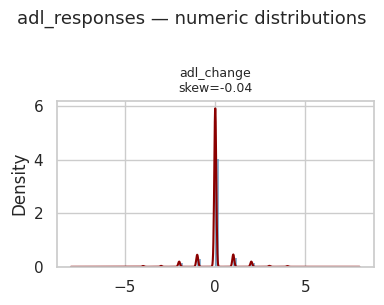

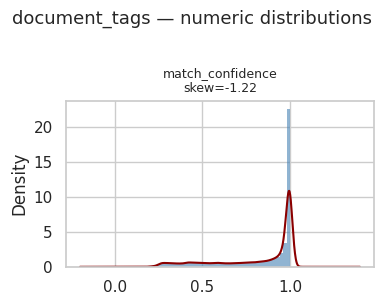

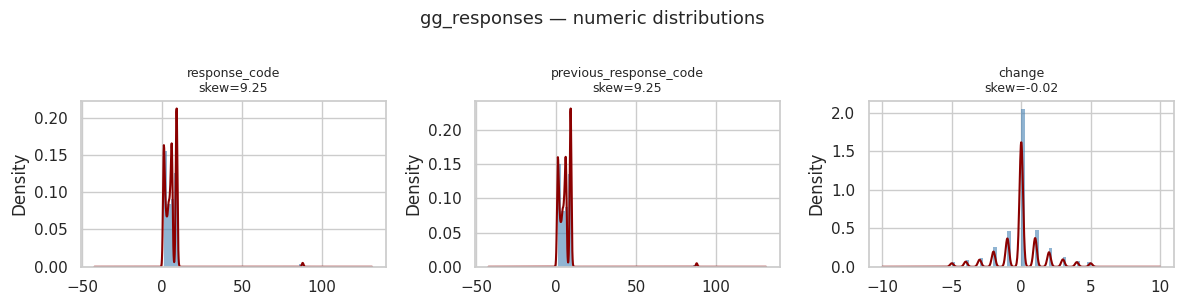

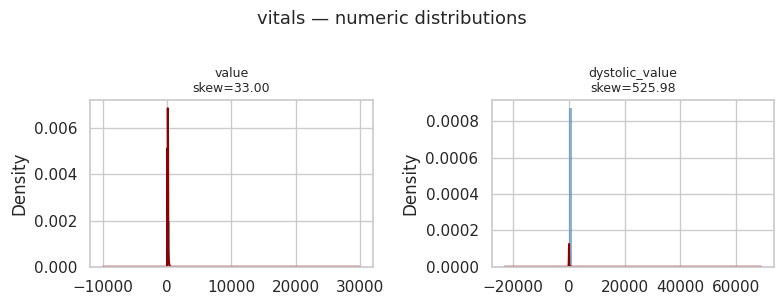

In [9]:
# Distribution plots — numeric columns per dataset (hist + KDE)
for name, df in dfs.items():
    num_cols = df.select_dtypes(include="number").columns.tolist()
    if not num_cols:
        continue
    n_cols = min(len(num_cols), 4)
    n_rows = int(np.ceil(len(num_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
    axes = np.array(axes).flatten()
    fig.suptitle(f"{name} — numeric distributions", fontsize=13, y=1.01)
    for i, col in enumerate(num_cols):
        data = df[col].dropna()
        axes[i].hist(data, bins=40, density=True, alpha=0.6, color="steelblue", edgecolor="none")
        try:
            data.plot.kde(ax=axes[i], color="darkred", lw=1.5)
        except Exception:
            pass
        skew_val = data.skew()
        axes[i].set_title(f"{col}\nskew={skew_val:.2f}", fontsize=9)
        axes[i].set_xlabel("")
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()

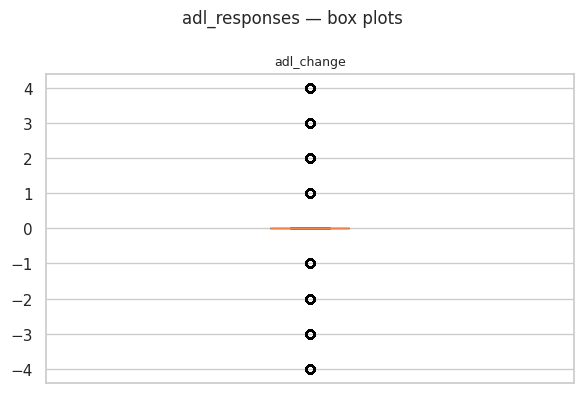

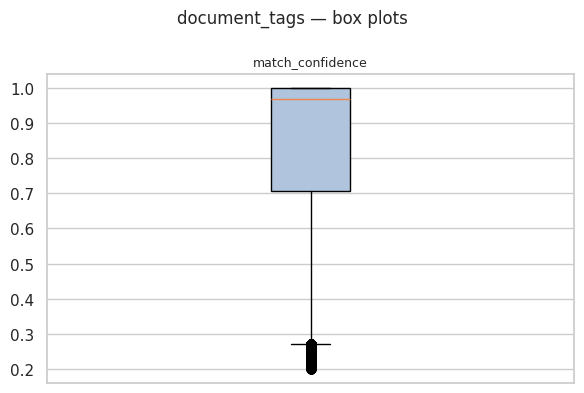

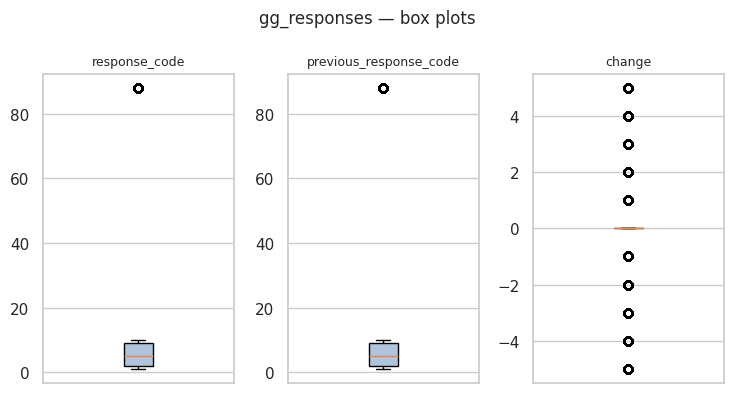

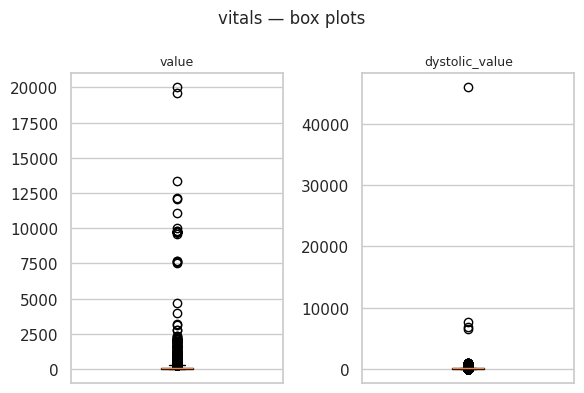

In [10]:
# Box plots to visualise spread and outliers
for name, df in dfs.items():
    num_cols = df.select_dtypes(include="number").columns.tolist()
    if not num_cols:
        continue
    fig, axes = plt.subplots(1, len(num_cols), figsize=(max(6, 2.5 * len(num_cols)), 4))
    if len(num_cols) == 1:
        axes = [axes]
    fig.suptitle(f"{name} — box plots", fontsize=12)
    for ax, col in zip(axes, num_cols):
        ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
                   boxprops=dict(facecolor="lightsteelblue"))
        ax.set_title(col, fontsize=9)
        ax.set_xticks([])
    plt.tight_layout()
    plt.show()

## 5. Intra-dataset Feature Relationships (Correlation)

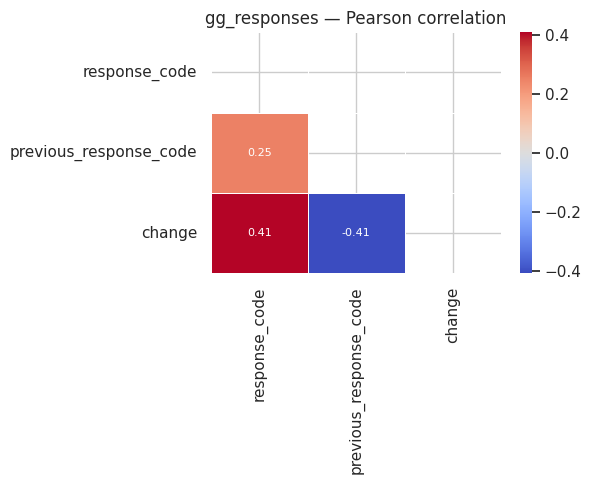

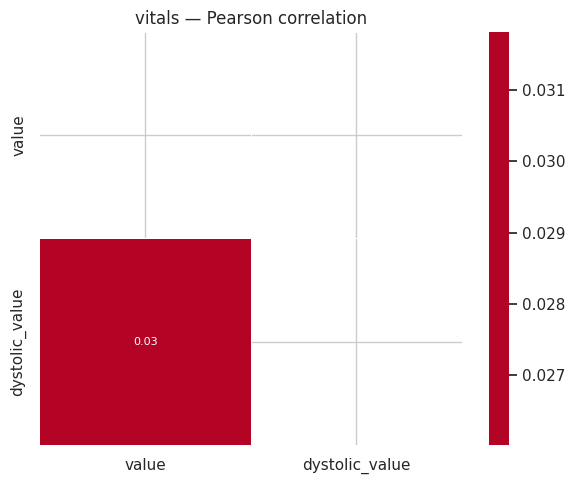

In [11]:
# Pearson correlation heatmaps — one per dataset with ≥2 numeric columns
for name, df in dfs.items():
    num_cols = df.select_dtypes(include="number").columns.tolist()
    if len(num_cols) < 2:
        continue
    corr = df[num_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    fig, ax = plt.subplots(figsize=(max(6, 0.7 * len(num_cols)), max(5, 0.6 * len(num_cols))))
    sns.heatmap(
        corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
        center=0, linewidths=0.4, ax=ax, annot_kws={"size": 8}
    )
    ax.set_title(f"{name} — Pearson correlation", fontsize=12)
    plt.tight_layout()
    plt.show()

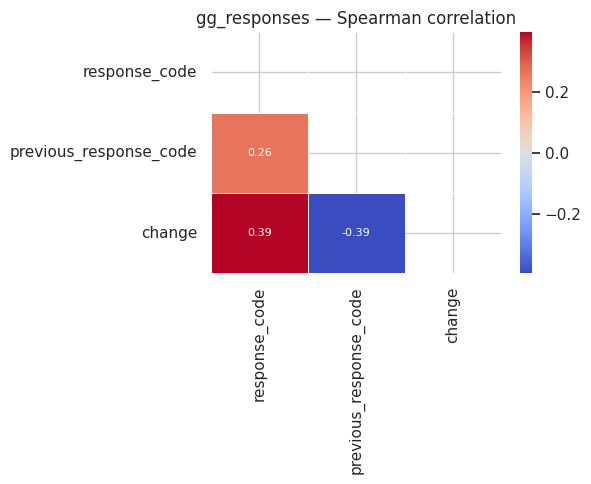

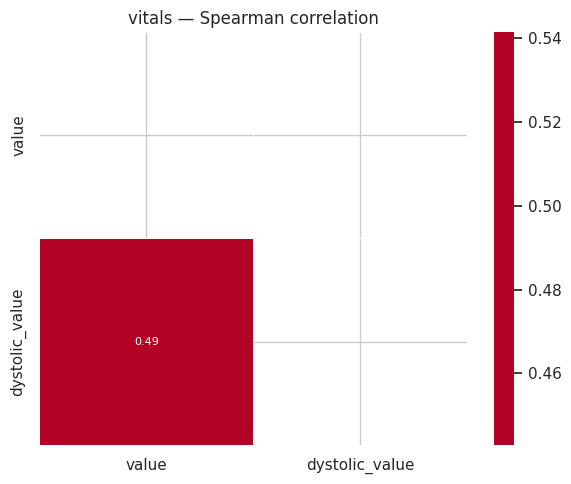

In [13]:
# Spearman correlation (rank-based, better for skewed/ordinal data)
for name, df in dfs.items():
    num_cols = df.select_dtypes(include="number").columns.tolist()
    if len(num_cols) < 2:
        continue
    corr = df[num_cols].corr(method="spearman")
    mask = np.triu(np.ones_like(corr, dtype=bool))
    fig, ax = plt.subplots(figsize=(max(6, 0.7 * len(num_cols)), max(5, 0.6 * len(num_cols))))
    sns.heatmap(
        corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
        center=0, linewidths=0.4, ax=ax, annot_kws={"size": 8}
    )
    ax.set_title(f"{name} — Spearman correlation", fontsize=12)
    plt.tight_layout()
    plt.show()

## 6. Inter-dataset Relationships

Identify shared keys (join columns) across datasets, then explore cross-dataset linkage and coverage.

In [14]:
# Find shared column names across all datasets
from itertools import combinations

col_sets = {name: set(df.columns) for name, df in dfs.items()}
shared_keys = []
for (a, cols_a), (b, cols_b) in combinations(col_sets.items(), 2):
    shared = cols_a & cols_b
    if shared:
        shared_keys.append({"dataset_a": a, "dataset_b": b, "shared_columns": sorted(shared)})

shared_df = pd.DataFrame(shared_keys)
shared_df

,dataset_a,dataset_b,shared_columns
0,adl_responses,care_plans,"[created_at, facility_id, resident_id]"
1,adl_responses,diagnoses,"[created_at, facility_id, resident_id]"
2,adl_responses,document_tags,"[created_at, facility_id, resident_id]"
3,adl_responses,factors,"[created_at, facility_id]"
4,adl_responses,gg_responses,"[created_at, facility_id, resident_id, response]"
...,...,...,...
131,physician_orders,therapy_tracks,"[created_at, end_at, facility_id, resident_id,..."
132,physician_orders,vitals,"[created_at, facility_id, resident_id]"
133,residents,therapy_tracks,"[created_at, facility_id, resident_id]"
134,residents,vitals,"[created_at, facility_id, resident_id]"


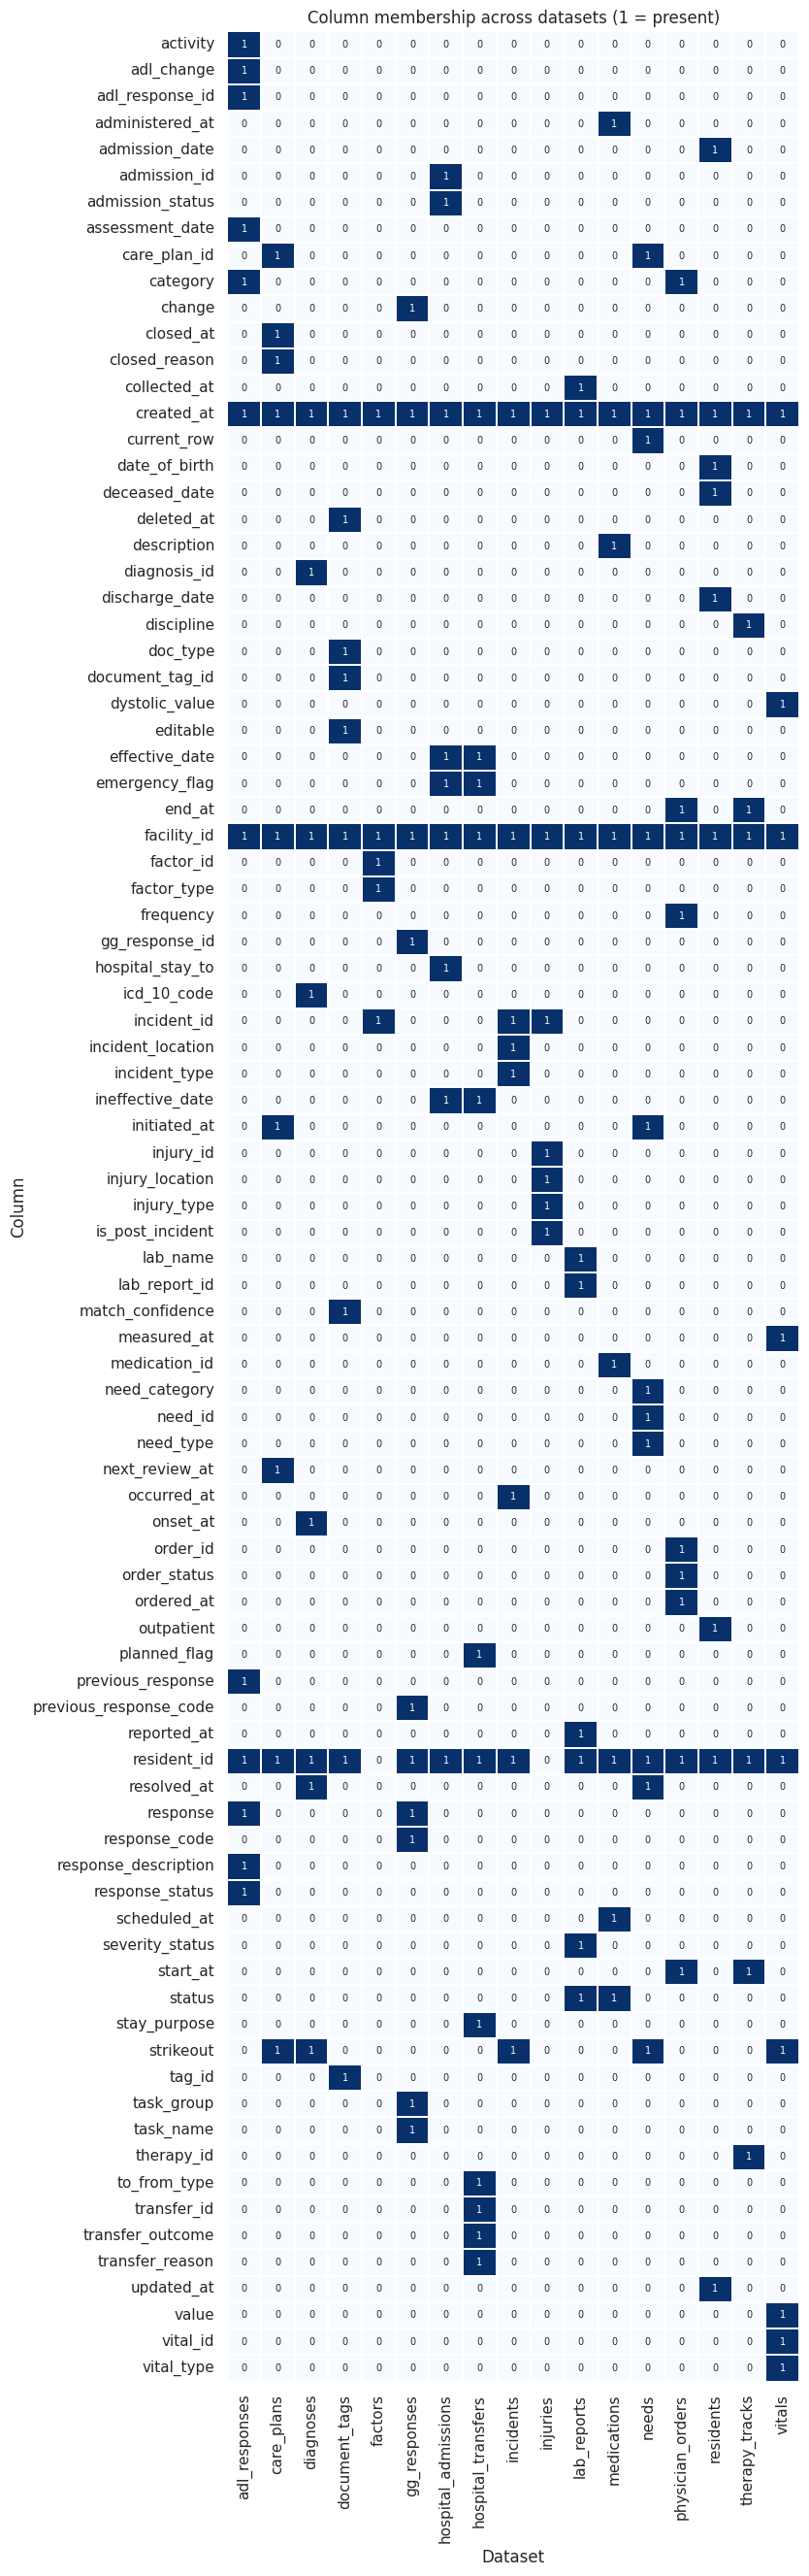

In [15]:
# Column membership matrix — which datasets have each column
all_cols = sorted(set(col for cols in col_sets.values() for col in cols))
membership = pd.DataFrame(
    {col: {name: col in cols for name, cols in col_sets.items()} for col in all_cols}
).T
membership.columns.name = "dataset"
membership = membership.astype(int)

fig, ax = plt.subplots(figsize=(max(8, 0.5 * len(dfs)), max(6, 0.3 * len(all_cols))))
sns.heatmap(membership, annot=True, fmt="d", cmap="Blues", cbar=False,
            linewidths=0.3, ax=ax, annot_kws={"size": 7})
ax.set_title("Column membership across datasets (1 = present)", fontsize=12)
ax.set_xlabel("Dataset")
ax.set_ylabel("Column")
plt.tight_layout()
plt.show()

In [16]:
# Resident coverage — how many unique residents appear in each dataset vs the master list
resident_id_candidates = [c for c in all_cols if "resident" in c.lower() or c.lower() in ("id", "resident_id")]
print("Candidate resident ID columns:", resident_id_candidates)

# Try to find the resident identifier automatically
for candidate in resident_id_candidates:
    coverage = {}
    for name, df in dfs.items():
        if candidate in df.columns:
            coverage[name] = df[candidate].nunique()
    if coverage:
        print(f"\nUnique values of '{candidate}' per dataset:")
        for k, v in sorted(coverage.items(), key=lambda x: -x[1]):
            print(f"  {k:30s}  {v:,}")

Candidate resident ID columns: ['resident_id']

Unique values of 'resident_id' per dataset:
  residents                       3,000
  care_plans                      2,745
  diagnoses                       2,547
  needs                           2,490
  vitals                          2,465
  physician_orders                2,399
  hospital_admissions             1,873
  lab_reports                     1,171
  document_tags                   1,018
  incidents                       987
  hospital_transfers              911
  medications                     481
  therapy_tracks                  219
  gg_responses                    134
  adl_responses                   96


In [17]:
# Inter-dataset join: link incidents to other datasets on shared keys
# First look at incidents schema
incidents = dfs["incidents"]
print("incidents columns:", incidents.columns.tolist())
print(incidents.head(3).T)

incidents columns: ['incident_id', 'facility_id', 'resident_id', 'incident_type', 'incident_location', 'occurred_at', 'strikeout', 'created_at']
                                                      0  \
incident_id        0d32dafc-e91c-5360-aefd-55e0f98943d6   
facility_id        0240d706-3348-5117-8d03-b06c5141e8c0   
resident_id        e681d7c1-a733-57cf-86cd-fd57e3b02f39   
incident_type                                      Fall   
incident_location                       Resident's Room   
occurred_at                         2024-11-13 05:10:00   
strikeout                                         False   
created_at                   2024-11-13 05:45:31.053000   

                                                      1  \
incident_id        447f3407-8ccb-5e86-8469-7e0af5314ade   
facility_id        0240d706-3348-5117-8d03-b06c5141e8c0   
resident_id        207a6546-03d7-5343-a214-299291a28151   
incident_type                                      Fall   
incident_location           

In [18]:
# For each dataset, compute intersection of its IDs with incidents IDs on each shared key
incident_cols = set(incidents.columns)

for name, df in dfs.items():
    if name == "incidents":
        continue
    shared = incident_cols & set(df.columns)
    if not shared:
        continue
    for key in shared:
        inc_ids = set(incidents[key].dropna().unique())
        ds_ids = set(df[key].dropna().unique())
        overlap = len(inc_ids & ds_ids)
        print(
            f"incidents ↔ {name} on '{key}': "
            f"{overlap:,} / {len(inc_ids):,} incident IDs covered "
            f"({100*overlap/len(inc_ids):.1f}%)"
        )

incidents ↔ adl_responses on 'facility_id': 9 / 92 incident IDs covered (9.8%)
incidents ↔ adl_responses on 'created_at': 0 / 3,578 incident IDs covered (0.0%)
incidents ↔ adl_responses on 'resident_id': 45 / 987 incident IDs covered (4.6%)
incidents ↔ care_plans on 'facility_id': 92 / 92 incident IDs covered (100.0%)
incidents ↔ care_plans on 'created_at': 0 / 3,578 incident IDs covered (0.0%)
incidents ↔ care_plans on 'resident_id': 973 / 987 incident IDs covered (98.6%)
incidents ↔ care_plans on 'strikeout': 2 / 2 incident IDs covered (100.0%)
incidents ↔ diagnoses on 'facility_id': 91 / 92 incident IDs covered (98.9%)
incidents ↔ diagnoses on 'strikeout': 2 / 2 incident IDs covered (100.0%)
incidents ↔ diagnoses on 'created_at': 0 / 3,578 incident IDs covered (0.0%)
incidents ↔ diagnoses on 'resident_id': 945 / 987 incident IDs covered (95.7%)
incidents ↔ document_tags on 'facility_id': 35 / 92 incident IDs covered (38.0%)
incidents ↔ document_tags on 'created_at': 0 / 3,578 incide

## 7. Target Variable Deep-Dive — Incidents

In [19]:
inc = dfs["incidents"].copy()
print(f"Shape: {inc.shape}")
display(inc.head())
display(inc.dtypes)

Shape: (3578, 8)


,incident_id,facility_id,resident_id,incident_type,incident_location,occurred_at,strikeout,created_at
0,0d32dafc-e91c-5360-aefd-55e0f98943d6,0240d706-3348-5117-8d03-b06c5141e8c0,e681d7c1-a733-57cf-86cd-fd57e3b02f39,Fall,Resident's Room,2024-11-13 05:10:00,False,2024-11-13 05:45:31.053
1,447f3407-8ccb-5e86-8469-7e0af5314ade,0240d706-3348-5117-8d03-b06c5141e8c0,207a6546-03d7-5343-a214-299291a28151,Fall,Resident's Room,2024-10-09 17:47:00,False,2024-10-09 17:48:02.573
2,4860a3b6-9edf-53ec-841a-1c5a15b84709,0240d706-3348-5117-8d03-b06c5141e8c0,725efbae-bafc-53a6-bfa5-ff3ad771f447,Fall,Dining Room,2024-08-09 20:31:00,False,2024-08-10 07:32:38.360
3,fc29a329-6305-597f-94df-2b4b81ca8b76,0240d706-3348-5117-8d03-b06c5141e8c0,0dc1285a-6858-543e-9c46-202e9b82a328,Fall,Resident's Room,2024-11-28 20:50:00,False,2024-11-28 21:04:13.683
4,32c20bda-59f7-5aa0-ba20-250fe9aa9c45,0240d706-3348-5117-8d03-b06c5141e8c0,207a6546-03d7-5343-a214-299291a28151,Fall,Resident's Room,2024-09-28 18:20:00,False,2024-09-28 18:20:24.140


incident_id                     str
facility_id                     str
resident_id                     str
incident_type                   str
incident_location               str
occurred_at          datetime64[us]
strikeout                      bool
created_at           datetime64[us]
dtype: object

Candidate type columns: ['incident_type']


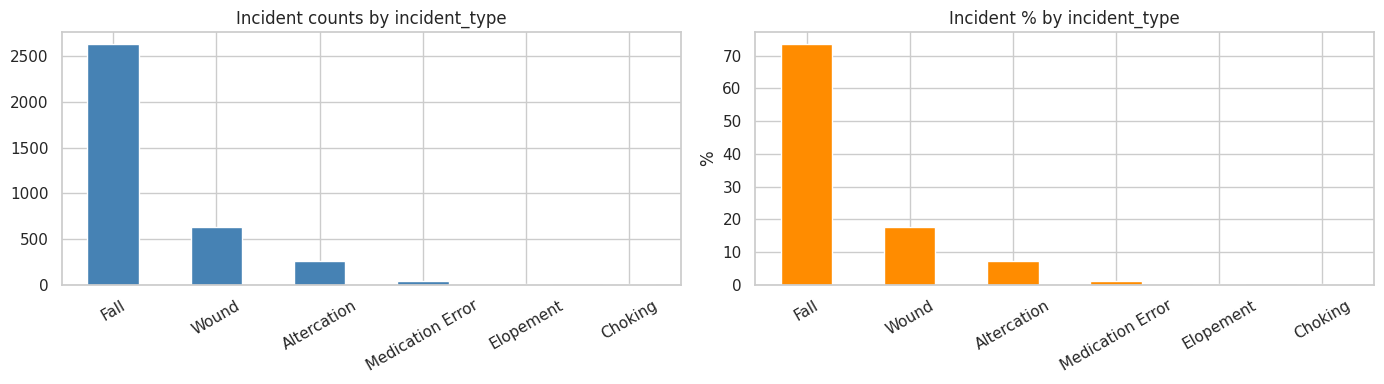

In [20]:
# Incident type frequency
type_cols = [c for c in inc.columns if "type" in c.lower() or "category" in c.lower() or "kind" in c.lower()]
print("Candidate type columns:", type_cols)

for col in type_cols:
    vc = inc[col].value_counts()
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    vc.plot.bar(ax=axes[0], color="steelblue")
    axes[0].set_title(f"Incident counts by {col}")
    axes[0].set_xlabel("")
    axes[0].tick_params(axis="x", rotation=30)
    (100 * vc / len(inc)).plot.bar(ax=axes[1], color="darkorange")
    axes[1].set_title(f"Incident % by {col}")
    axes[1].set_xlabel("")
    axes[1].tick_params(axis="x", rotation=30)
    axes[1].set_ylabel("%")
    plt.tight_layout()
    plt.show()

Candidate date columns: ['incident_location', 'occurred_at', 'created_at']


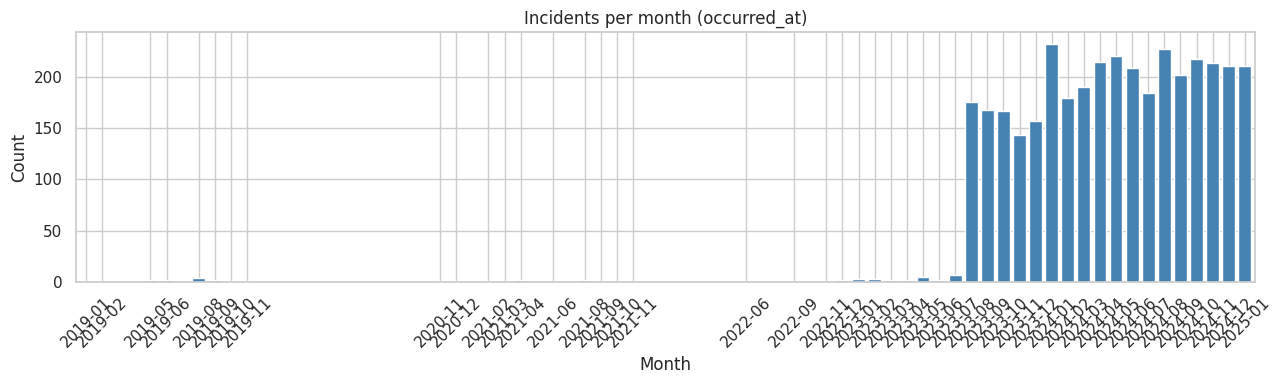

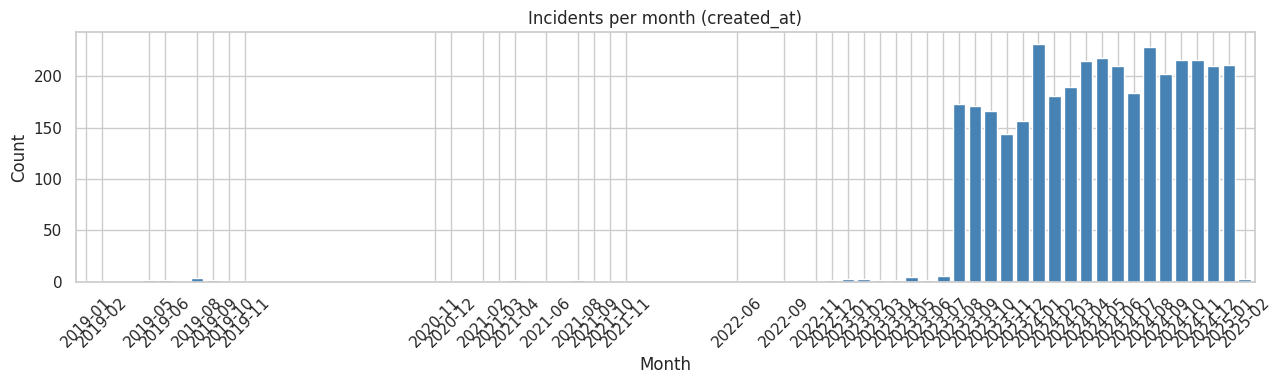

In [21]:
# Incidents over time
date_cols = [c for c in inc.columns if inc[c].dtype in ["datetime64[ns]", "datetime64[us]"]
             or "date" in c.lower() or "time" in c.lower() or "at" in c.lower()]
print("Candidate date columns:", date_cols)

for col in date_cols:
    try:
        ts = pd.to_datetime(inc[col], errors="coerce")
        if ts.isna().all():
            continue
        fig, ax = plt.subplots(figsize=(13, 4))
        ts.dt.to_period("M").value_counts().sort_index().plot.bar(ax=ax, color="steelblue", width=0.8)
        ax.set_title(f"Incidents per month ({col})")
        ax.set_xlabel("Month")
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=45)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"  Skipping {col}: {e}")

count   987.0000
mean      3.6251
std       4.9053
min       1.0000
25%       1.0000
50%       2.0000
75%       4.0000
max      52.0000
Name: incident_count, dtype: float64


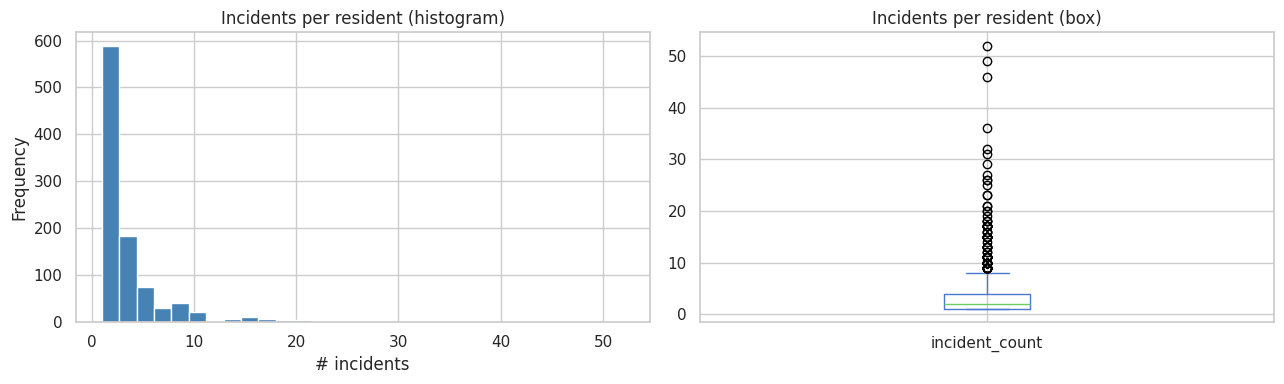


Residents with 0 incidents (in residents table but not incidents):
  2,013 / 3,000 residents never had an incident


In [22]:
# Incident rate per resident (how many incidents does each resident have?)
res_id_col = next((c for c in inc.columns if "resident" in c.lower()), None)
if res_id_col:
    per_resident = inc.groupby(res_id_col).size().rename("incident_count")
    print(per_resident.describe())
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    per_resident.plot.hist(bins=30, ax=axes[0], color="steelblue")
    axes[0].set_title("Incidents per resident (histogram)")
    axes[0].set_xlabel("# incidents")
    per_resident.plot.box(ax=axes[1])
    axes[1].set_title("Incidents per resident (box)")
    plt.tight_layout()
    plt.show()
    print(f"\nResidents with 0 incidents (in residents table but not incidents):")
    if res_id_col in dfs.get("residents", pd.DataFrame()).columns:
        all_res = set(dfs["residents"][res_id_col])
        inc_res = set(inc[res_id_col].dropna())
        print(f"  {len(all_res - inc_res):,} / {len(all_res):,} residents never had an incident")

In [23]:
# Incident severity / injury breakdown (linked via injuries table)
if "injuries" in dfs:
    inj = dfs["injuries"]
    print("injuries columns:", inj.columns.tolist())
    display(inj.head())

    # join to incidents if possible
    shared = set(inc.columns) & set(inj.columns)
    print(f"\nShared keys: {shared}")
    if shared:
        key = next(iter(shared))
        merged = inc.merge(inj, on=key, how="left", suffixes=("_inc", "_inj"))
        sev_col = next((c for c in merged.columns if "sever" in c.lower() or "level" in c.lower()), None)
        if sev_col:
            vc = merged[sev_col].value_counts(dropna=False)
            vc.plot.bar(color="tomato")
            plt.title(f"Injury severity distribution ({sev_col})")
            plt.tight_layout()
            plt.show()

injuries columns: ['injury_id', 'incident_id', 'facility_id', 'injury_type', 'injury_location', 'is_post_incident', 'created_at']


,injury_id,incident_id,facility_id,injury_type,injury_location,is_post_incident,created_at
0,ecb65a51-6852-57fa-9623-ef2e442b4260,0d32dafc-e91c-5360-aefd-55e0f98943d6,0240d706-3348-5117-8d03-b06c5141e8c0,Bruise,4) Face,False,2026-01-15 19:04:08.987
1,27587027-f4f5-5d98-976a-4757aab08d90,5c5787a4-9f95-503d-9f69-557072a22564,0240d706-3348-5117-8d03-b06c5141e8c0,Skin Tear,60) Right Forearm,False,2026-01-15 19:04:08.987
2,6686ae30-7dba-5bf2-a6b8-f5745353bbd1,8eebb22c-c34b-581a-9e4f-abeb9b60c992,0240d706-3348-5117-8d03-b06c5141e8c0,Skin Tear,29) Right hand (back),False,2026-01-15 19:04:08.987
3,4ef5ce20-f381-55bc-81c3-c235f91f4793,0d32dafc-e91c-5360-aefd-55e0f98943d6,0240d706-3348-5117-8d03-b06c5141e8c0,Hematoma,1) Top of Scalp,False,2026-01-15 19:04:08.987
4,960a590b-9cbe-5c2d-b7ce-ad9d46c139b2,f7e18c0a-1671-5e09-b39c-de282148700e,0240d706-3348-5117-8d03-b06c5141e8c0,Abrasion,60) Other,True,2026-01-15 19:04:08.987



Shared keys: {'facility_id', 'created_at', 'incident_id'}


## 8. Inter-dataset Feature Relationships — Numeric Cross-Joins

Join key clinical datasets to incidents and compute correlations between clinical features and incident count per resident.

In [24]:
# Build resident-level incident count as target
res_id_col = next((c for c in inc.columns if "resident" in c.lower()), None)
assert res_id_col, "No resident ID column found in incidents"

incident_counts = inc.groupby(res_id_col).size().reset_index(name="incident_count")
print(f"Resident-level incident counts: {len(incident_counts):,} residents")
incident_counts["incident_count"].describe()

Resident-level incident counts: 987 residents


count   987.0000
mean      3.6251
std       4.9053
min       1.0000
25%       1.0000
50%       2.0000
75%       4.0000
max      52.0000
Name: incident_count, dtype: float64

In [25]:
# For each dataset that shares the resident ID: aggregate numeric cols to resident level,
# join to incident_counts, and compute correlations with incident_count
cross_corrs = []

for name, df in dfs.items():
    if name in ("incidents", "injuries", "residents"):
        continue
    if res_id_col not in df.columns:
        continue
    num_cols = df.select_dtypes(include="number").columns.tolist()
    if not num_cols:
        continue

    # aggregate: mean of numeric cols per resident
    agg = df.groupby(res_id_col)[num_cols].mean().reset_index()
    merged = incident_counts.merge(agg, on=res_id_col, how="inner")

    for col in num_cols:
        if merged[col].std() == 0:
            continue
        r = merged[["incident_count", col]].corr(method="spearman").iloc[0, 1]
        cross_corrs.append({"dataset": name, "feature": col, "spearman_r": round(r, 4), "n": len(merged)})

cross_df = pd.DataFrame(cross_corrs).sort_values("spearman_r", key=abs, ascending=False)
print("Top 30 cross-dataset features correlated with incident_count:")
display(cross_df.head(30))

Top 30 cross-dataset features correlated with incident_count:


,dataset,feature,spearman_r,n
4,gg_responses,change,-0.1672,68
0,adl_responses,adl_change,0.1471,45
1,document_tags,match_confidence,0.0857,375
3,gg_responses,previous_response_code,0.0309,68
2,gg_responses,response_code,0.0290,68
6,vitals,dystolic_value,0.0254,946
5,vitals,value,-0.0237,946


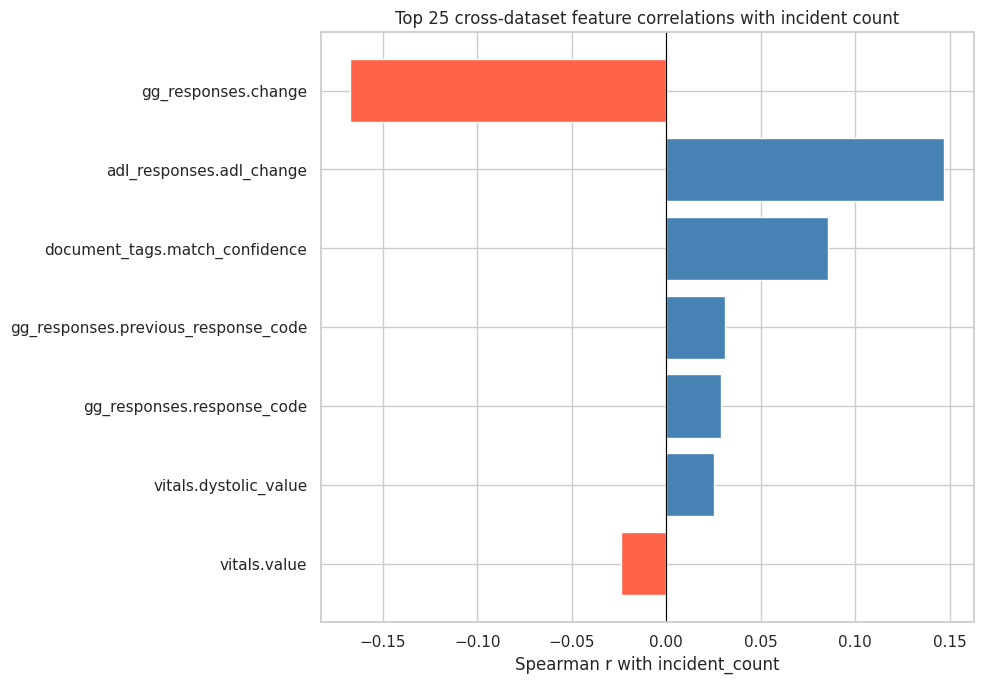

In [26]:
# Visualise top cross-dataset correlations
top_n = 25
plot_df = cross_df.head(top_n).copy()
plot_df["label"] = plot_df["dataset"] + "." + plot_df["feature"]
colors = ["tomato" if r < 0 else "steelblue" for r in plot_df["spearman_r"]]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_df["label"], plot_df["spearman_r"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Spearman r with incident_count")
ax.set_title(f"Top {top_n} cross-dataset feature correlations with incident count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

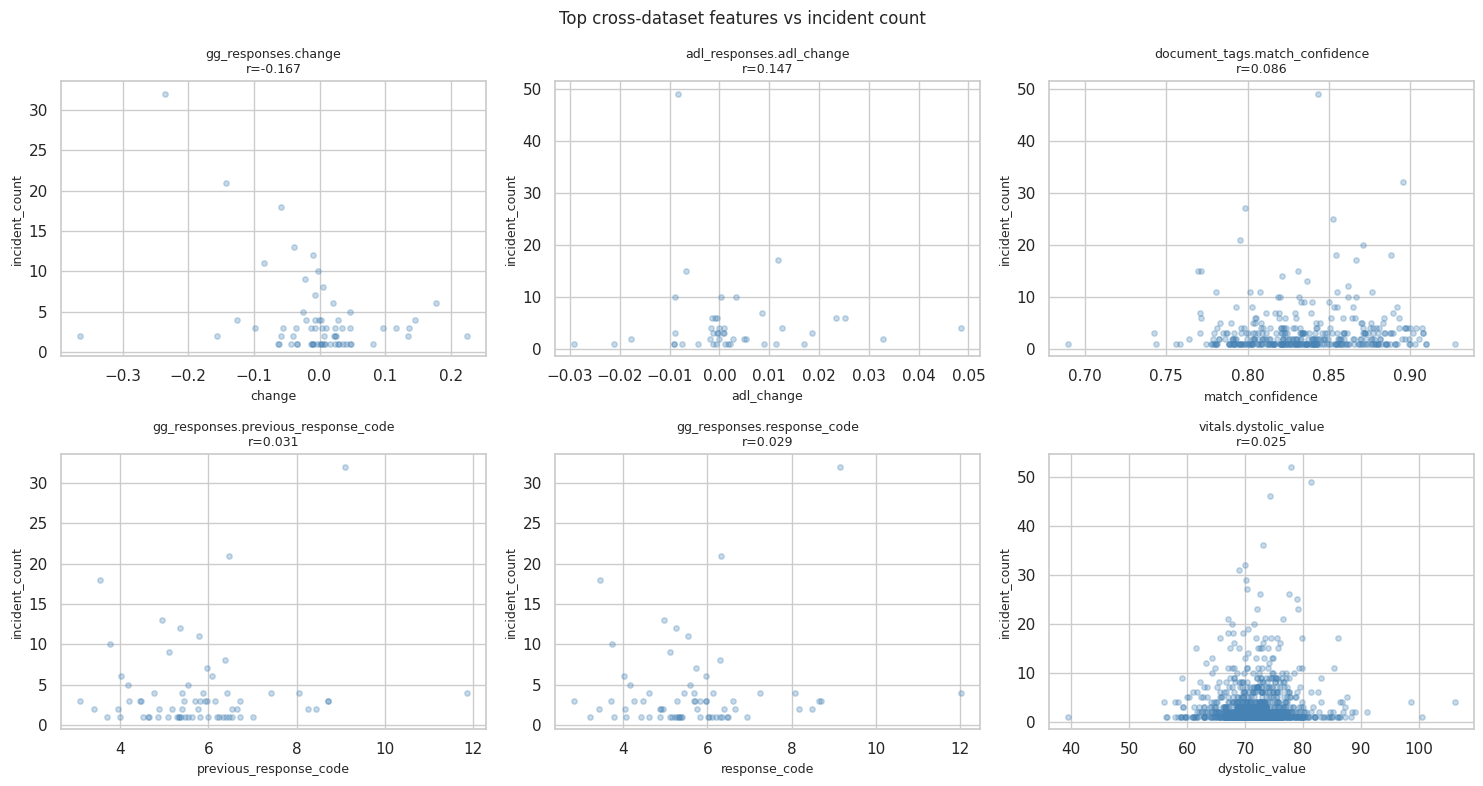

In [27]:
# Scatter plots for top 6 cross-dataset features vs incident_count
top_features = cross_df.head(6)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (_, row) in enumerate(top_features.iterrows()):
    ds_name, feat = row["dataset"], row["feature"]
    df = dfs[ds_name]
    if res_id_col not in df.columns:
        continue
    agg = df.groupby(res_id_col)[feat].mean().reset_index()
    plot_data = incident_counts.merge(agg, on=res_id_col, how="inner")
    axes[i].scatter(plot_data[feat], plot_data["incident_count"], alpha=0.3, s=15, color="steelblue")
    axes[i].set_xlabel(feat, fontsize=9)
    axes[i].set_ylabel("incident_count", fontsize=9)
    axes[i].set_title(f"{ds_name}.{feat}\nr={row['spearman_r']:.3f}", fontsize=9)

plt.suptitle("Top cross-dataset features vs incident count", fontsize=12)
plt.tight_layout()
plt.show()